# Extended-conflict participant (oy): psychometric functions and PSE vs conflict

Single-participant analysis using `data/oyExt_all.csv`, which combines the original main-experiment trials with new extended-conflict trials at ±0.45.

Mirrors the structure of `plotConflictvsPSE.ipynb` but:
- single participant, so per-condition bootstrap is over trials (not participants),
- fits a mode-selectable PF per (audNoise, conflict) with a custom binomial NLL + `scipy.optimize.minimize` (no `curve_fit`),
- conflicts include ±0.45 and the legend / x-ticks reflect that.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import erf
from scipy.stats import norm

import loadData
import monteCarloClass

# Publication-style figure params (match plotConflictvsPSE.ipynb)
FONT_SIZE_LABEL = 18
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 20
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABEL,
    'xtick.labelsize': FONT_SIZE_LABEL,
    'ytick.labelsize': FONT_SIZE_LABEL,
    'legend.fontsize': FONT_SIZE_LEGEND,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

STANDARD_S  = 0.5
STANDARD_MS = 500

## 1. Load data and canonicalise conflicts

Sessions stored conflicts with slight float jitter (e.g. -0.25067 vs -0.25166). Snap each trial's `conflictDur` to its nearest canonical value before grouping.

In [8]:
data, dataName = loadData.loadData('dt_all.csv', verbose=False)
print('dataName:', dataName)
print('shape:', data.shape)

CANONICAL_CONFLICTS_S = np.array([-0.45, -0.25, -0.17, -0.08, 0.0, 0.08, 0.17, 0.25, 0.45])

def snap_conflict(c, canonical=CANONICAL_CONFLICTS_S):
    idx = int(np.argmin(np.abs(canonical - c)))
    return float(canonical[idx])

data['conflictDur'] = data['conflictDur'].apply(snap_conflict)
print('conflictDur (ms) after snap:', sorted({int(round(c * 1000)) for c in data['conflictDur'].unique()}))
print('audNoise unique:', sorted(data['audNoise'].unique()))

mc_fitter = monteCarloClass.OmerMonteCarlo(data)
groupedData = mc_fitter.groupByChooseTest(data)
print('grouped rows:', len(groupedData))
groupedData.head()

dataName: dt_all
shape: (2226, 59)
conflictDur (ms) after snap: [-250, -170, -80, 0, 80, 170, 250]
audNoise unique: [np.float64(0.1), np.float64(1.2)]
grouped rows: 360


,deltaDurS,audNoise,standardDur,conflictDur,num_of_chose_test,total_responses,num_of_chose_standard,p_choose_test
0,-0.29193,0.1,0.5,-0.25,1,7,6,0.142857
1,-0.29193,0.1,0.5,0.08,0,7,7,0.000000
2,-0.29193,1.2,0.5,-0.25,2,13,11,0.153846
3,-0.29193,1.2,0.5,0.08,1,3,2,0.333333
4,-0.29178,0.1,0.5,-0.17,1,8,7,0.125000


## 2. Per-condition PF fits (binomial NLL + scipy.minimize)

Set `PF_MODE = 'lognormal'` for $\log(\mathrm{testDur}/\mathrm{standardDur})$, or `PF_MODE = 'normal'` for $\mathrm{testDur} - \mathrm{standardDur}$.
Binomial NLL:
$$ \mathrm{NLL}(\mu, \sigma, \lambda) = -\sum_\Delta \big[ n_\text{chose}(\Delta)\,\log p_\text{model}(\Delta) + (n_\text{total}-n_\text{chose})(\Delta)\,\log(1-p_\text{model}(\Delta)) \big] $$
Minimised with L-BFGS-B from 4 starts; best result kept.

In [10]:
PF_MODE = 'lognormal'  # 'lognormal' or 'normal'
VALID_PF_MODES = {'lognormal', 'normal'}
if PF_MODE not in VALID_PF_MODES:
    raise ValueError(f'PF_MODE must be one of {VALID_PF_MODES}, got {PF_MODE!r}')


def pf_input_from_durations(test_durs, standard_durs):
    test_durs = np.asarray(test_durs, dtype=float)
    standard_durs = np.asarray(standard_durs, dtype=float)
    if PF_MODE == 'lognormal':
        return np.log(test_durs / standard_durs)
    return test_durs - standard_durs


def psychometric_pf(pf_x, mu, sigma, lam):
    return lam / 2.0 + (1.0 - lam) * norm.cdf((pf_x - mu) / sigma)


def mu_to_shift_s(mu, standard_s=STANDARD_S):
    if PF_MODE == 'lognormal':
        return standard_s * (np.exp(mu) - 1.0)
    return mu


def sigma_to_plot_units(sigma, standard_s=STANDARD_S):
    if PF_MODE == 'lognormal':
        return sigma
    return sigma / standard_s


def sigma_plot_label():
    return 'PF $\\sigma$ (log units)' if PF_MODE == 'lognormal' else 'PF $\\sigma$ / standard duration'


def _binom_nll(params, pf_x, n_chose, n_total):
    mu, sigma, lam = params
    if sigma <= 0 or lam < BOUNDS[2][0] or lam > BOUNDS[2][1]:
        return 1e10
    p = psychometric_pf(pf_x, mu, sigma, lam)
    eps = 1e-9
    p = np.clip(p, eps, 1.0 - eps)
    return -float(np.sum(n_chose * np.log(p)
                         + (n_total - n_chose) * np.log(1.0 - p)))


BOUNDS = [(-1.0, 1.0), (0.01, 3.0), (0.0, 0.25)] if PF_MODE == 'lognormal' else [(-0.6, 0.6), (1e-3, 1.5), (0.0, 0.4)]
INITS = [
    [0.0,  0.10, 0.02],
    [0.0,  0.05, 0.02],
    [0.05, 0.20, 0.05],
    [-0.05, 0.30, 0.02],
]


def fit_pf(pf_x, n_chose, n_total):
    best = None
    for x0 in INITS:
        try:
            res = minimize(_binom_nll, x0, args=(pf_x, n_chose, n_total),
                           bounds=BOUNDS, method='L-BFGS-B')
            if res.success and (best is None or res.fun < best.fun):
                best = res
        except Exception:
            continue
    if best is None:
        return np.array([np.nan, np.nan, np.nan]), np.nan
    return best.x, float(best.fun)


def fit_per_condition(grouped):
    rows = []
    for noise in sorted(grouped['audNoise'].unique()):
        for conflict in sorted(grouped['conflictDur'].unique()):
            sub = grouped[(np.isclose(grouped['audNoise'], noise))
                          & (np.isclose(grouped['conflictDur'], conflict))]
            if len(sub) < 3:
                continue
            test_durs = sub['standardDur'].values.astype(float) + sub['deltaDurS'].values.astype(float)
            standard_durs = sub['standardDur'].values.astype(float)
            pf_x = pf_input_from_durations(test_durs, standard_durs)
            n_chose = sub['num_of_chose_test'].values.astype(float)
            n_total = sub['total_responses'].values.astype(float)
            (mu, sigma, lam), nll = fit_pf(pf_x, n_chose, n_total)
            rows.append(dict(audNoise=noise, conflict=conflict, mu=mu,
                             sigma=sigma, lam=lam, nll=nll,
                             N=int(n_total.sum())))
    return pd.DataFrame(rows)


fit_df = fit_per_condition(groupedData)
fit_df['conflict_ms'] = (fit_df['conflict'] * 1000).round().astype(int)
fit_df['mu_ms']       = mu_to_shift_s(fit_df['mu']) * 1000
fit_df['sigma_unitless'] = sigma_to_plot_units(fit_df['sigma'])
print(fit_df.round(3).to_string(index=False))

 audNoise  conflict     mu  sigma   lam     nll   N  conflict_ms    mu_ms  sigma_unitless
      0.1     -0.25 -0.088  0.306 0.196  85.208 164         -250  -42.133           0.306
      0.1     -0.17 -0.127  0.486 0.052  90.675 165         -170  -59.635           0.486
      0.1     -0.08 -0.061  0.383 0.000  84.619 164          -80  -29.774           0.383
      0.1      0.00 -0.049  0.272 0.250  76.390 140            0  -24.111           0.272
      0.1      0.08 -0.026  0.351 0.118  92.973 174           80  -12.624           0.351
      0.1      0.17  0.039  0.189 0.250  79.696 152          170   19.663           0.189
      0.1      0.25 -0.011  0.218 0.250  80.123 157          250   -5.287           0.218
      1.2     -0.25 -0.192  0.597 0.000  99.466 176         -250  -87.451           0.597
      1.2     -0.17 -0.276  0.669 0.250  89.904 143         -170 -120.559           0.669
      1.2     -0.08 -0.080  0.544 0.000  89.981 151          -80  -38.508           0.544
      1.2 

## 3. Trial-bootstrap 95% CIs on PSE

Within each (audNoise, conflict) cell, resample trials with replacement, refit the selected PF mode, and store μ and σ. μ CIs are converted to ms for plotting; σ is kept unitless.

In [11]:
N_BOOT = 50
rng = np.random.default_rng(0)


def bootstrap_condition(trials_df, n_boot=N_BOOT):
    """Bootstrap trials within one (noise, conflict) cell and refit selected PF mode.

    Returns arrays of bootstrap mu and sigma values (length n_boot).
    """
    pf_x_all = pf_input_from_durations(trials_df['testDurS'].values.astype(float),
                                       trials_df['standardDur'].values.astype(float))
    chose_all  = trials_df['chose_test'].values.astype(float)
    n_trials   = len(trials_df)
    mus, sigmas = np.empty(n_boot), np.empty(n_boot)
    mus[:]    = np.nan
    sigmas[:] = np.nan
    for b in range(n_boot):
        idx = rng.integers(0, n_trials, size=n_trials)
        pf_b, c_b = pf_x_all[idx], chose_all[idx]
        # Aggregate to per-PF-input binomial counts before fitting.
        unique_x, inv = np.unique(pf_b, return_inverse=True)
        n_total = np.bincount(inv).astype(float)
        n_chose = np.bincount(inv, weights=c_b).astype(float)
        if len(unique_x) < 3:
            continue
        (mu, sigma, _), _ = fit_pf(unique_x, n_chose, n_total)
        mus[b], sigmas[b] = mu, sigma
    return mus, sigmas


boot_rows = []
for noise in sorted(data['audNoise'].unique()):
    for conflict in sorted(data['conflictDur'].unique()):
        sub = data[(np.isclose(data['audNoise'], noise))
                   & (np.isclose(data['conflictDur'], conflict))]
        if len(sub) < 10:
            continue
        mus, sigmas = bootstrap_condition(sub)
        boot_rows.append(dict(
            audNoise=noise, conflict=conflict, conflict_ms=int(round(conflict * 1000)),
            n_trials=len(sub),
            mu_lo=float(np.nanpercentile(mus, 2.5)),
            mu_hi=float(np.nanpercentile(mus, 97.5)),
            mu_med=float(np.nanmedian(mus)),
            sigma_lo=float(np.nanpercentile(sigmas, 2.5)),
            sigma_hi=float(np.nanpercentile(sigmas, 97.5)),
            sigma_med=float(np.nanmedian(sigmas)),
        ))
boot_df = pd.DataFrame(boot_rows)
boot_df['mu_lo_ms'] = mu_to_shift_s(boot_df['mu_lo']) * 1000
boot_df['mu_hi_ms'] = mu_to_shift_s(boot_df['mu_hi']) * 1000
boot_df['mu_med_ms']= mu_to_shift_s(boot_df['mu_med']) * 1000
boot_df['sigma_lo_unitless'] = sigma_to_plot_units(boot_df['sigma_lo'])
boot_df['sigma_hi_unitless'] = sigma_to_plot_units(boot_df['sigma_hi'])
boot_df['sigma_med_unitless']= sigma_to_plot_units(boot_df['sigma_med'])
print(boot_df[['audNoise', 'conflict_ms', 'n_trials', 'mu_med_ms',
               'mu_lo_ms', 'mu_hi_ms', 'sigma_med_unitless']].round(3).to_string(index=False))

 audNoise  conflict_ms  n_trials  mu_med_ms  mu_lo_ms  mu_hi_ms  sigma_med_unitless
      0.1         -250       164    -45.536  -120.506     2.491               0.320
      0.1         -170       165    -58.106   -96.627    -7.534               0.411
      0.1          -80       164    -37.447   -67.553     6.111               0.388
      0.1            0       140    -22.982   -73.360    37.371               0.314
      0.1           80       174    -17.089   -61.608    28.263               0.341
      0.1          170       152     16.122   -63.685   113.619               0.174
      0.1          250       157     -3.781   -48.255    61.312               0.239
      1.2         -250       176    -95.694  -138.586   -41.004               0.531
      1.2         -170       143   -117.011  -258.214   -55.700               0.756
      1.2          -80       151    -43.153   -83.372     0.279               0.535
      1.2            0       168     41.631   -23.077   118.839             

## 4. Psychometric functions per (audNoise, conflict)

Reds = low audio noise (0.1), Blues = high audio noise (1.2). Conflicts coloured light-to-dark within each panel.

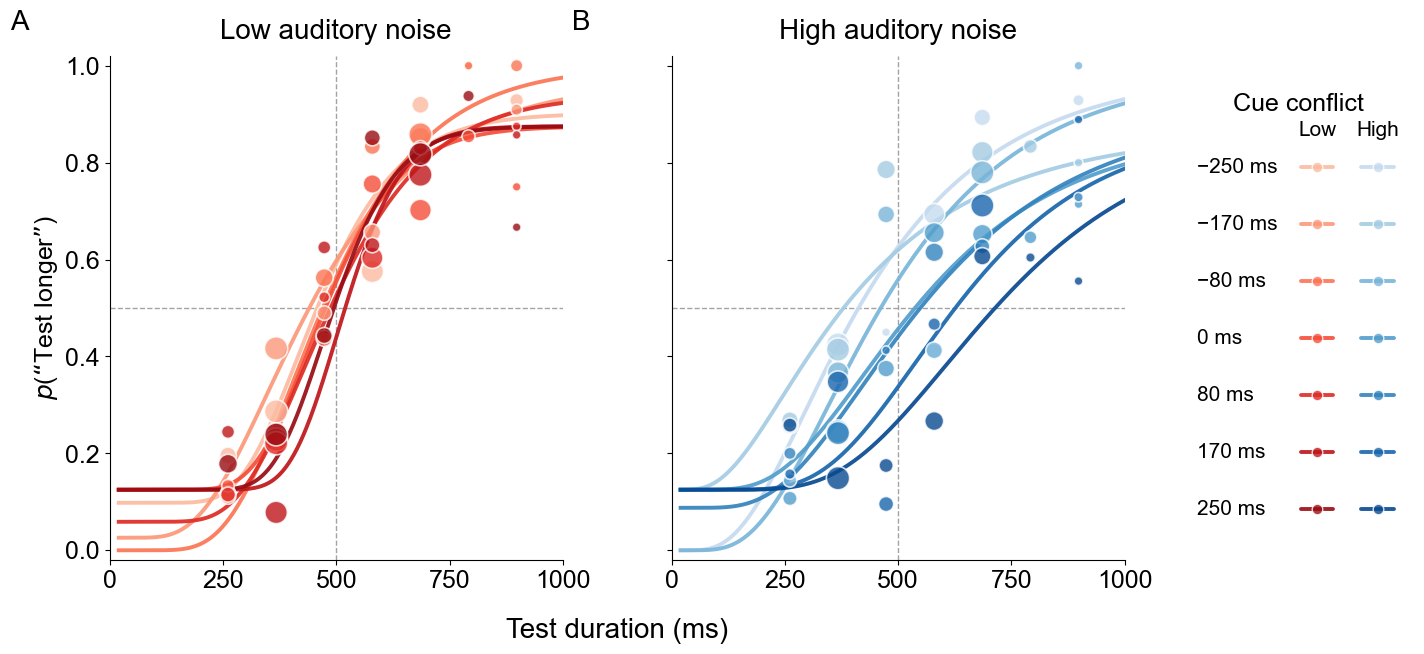

In [12]:
sensory_levels  = sorted(data['audNoise'].unique())
conflict_levels = sorted(data['conflictDur'].unique())

noise_cmaps = {
    sensory_levels[0]: sns.color_palette('Reds', as_cmap=True),
    sensory_levels[1]: sns.color_palette('Blues', as_cmap=True),
}
panel_labels = ['Low auditory noise', 'High auditory noise']
panel_tags = ['A', 'B']

n_conflicts = len(conflict_levels)


def conflict_color(noise, k):
    return noise_cmaps[noise](0.25 + 0.65 * k / max(n_conflicts - 1, 1))


# Shared bin grid in deltaDurS for the binned data points; PF curves use PF_MODE.
intensity = mc_fitter.intensityVar  # 'deltaDurS'
n_bins = 7
global_min = groupedData[intensity].min()
global_max = groupedData[intensity].max()
shared_bin_edges  = np.linspace(global_min, global_max, n_bins + 1)
shared_bin_centres_delta = 0.5 * (shared_bin_edges[:-1] + shared_bin_edges[1:])
shared_bin_centres_ms    = (shared_bin_centres_delta + STANDARD_S) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14.5, 7), sharey=True)

for j, audioNoise in enumerate(sensory_levels):
    ax = axes[j]
    for k, conflict in enumerate(conflict_levels):
        color = conflict_color(audioNoise, k)

        # PF curve from fitted (mu, sigma, lam)
        row = fit_df[(np.isclose(fit_df['audNoise'], audioNoise))
                     & (np.isclose(fit_df['conflict'], conflict))]
        if not row.empty:
            mu = float(row['mu'].iloc[0])
            sigma = float(row['sigma'].iloc[0])
            lam = float(row['lam'].iloc[0])
            x_fine_ms = np.linspace(20, 1050, 600)
            x_fine_s = x_fine_ms / 1000
            pf_x = pf_input_from_durations(x_fine_s, STANDARD_S)
            psi = psychometric_pf(pf_x, mu, sigma, lam)
            ax.plot(x_fine_ms, psi, color=color, linewidth=2.8, alpha=0.92, zorder=3)

        # Binned data points
        subset = groupedData[(np.isclose(groupedData['audNoise'], audioNoise))
                             & (np.isclose(groupedData['conflictDur'], conflict))].copy()
        if subset.empty:
            continue
        subset['bin'] = pd.cut(subset[intensity], bins=shared_bin_edges,
                                labels=False, include_lowest=True)
        binned = subset.groupby('bin').agg(
            y_mean=('p_choose_test', 'mean'),
            total_resp=('total_responses', 'sum'),
        ).dropna()
        if binned.empty:
            continue
        bin_indices = binned.index.astype(int)
        x_ms = shared_bin_centres_ms[bin_indices]
        max_resp, min_resp = binned['total_resp'].max(), binned['total_resp'].min()
        if max_resp > min_resp:
            sizes = 40 + (binned['total_resp'] - min_resp) / (max_resp - min_resp) * 240
        else:
            sizes = 120
        ax.scatter(x_ms, binned['y_mean'], s=sizes, color=color,
                   alpha=0.80, edgecolors='white', linewidths=1.2, zorder=5)

    ax.axhline(0.5, color='#999999', linestyle='--', linewidth=1.0, alpha=0.9)
    ax.axvline(STANDARD_MS, color='#999999', linestyle='--', linewidth=1.0, alpha=0.9)
    ax.set_xlim(0, 1000)
    ax.set_xticks([0, 250, 500, 750, 1000])
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(panel_labels[j], fontsize=FONT_SIZE_TITLE, loc='center', pad=12)
    ax.text(-0.22, 1.04, panel_tags[j], transform=ax.transAxes,
            ha='left', va='bottom', fontsize=FONT_SIZE_TITLE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)

axes[0].set_ylabel('$p$(“Test longer”)', fontsize=FONT_SIZE_LABEL)

# Right-side legend keyed by conflict, with both noise tints
def _fmt_ms(ms_int):
    return f'\u2212{abs(ms_int)} ms' if ms_int < 0 else f'{ms_int} ms'

legend_ax = fig.add_axes([0.82, 0.18, 0.16, 0.66])
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([]); legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(False)
legend_ax.text(0.5, 0.98, 'Cue conflict', ha='center', va='top',
               fontsize=FONT_SIZE_LEGEND - 2)
legend_ax.text(0.58, 0.90, 'Low', ha='center', va='center', fontsize=FONT_SIZE_LEGEND - 5)
legend_ax.text(0.84, 0.90, 'High', ha='center', va='center', fontsize=FONT_SIZE_LEGEND - 5)
y_positions = np.linspace(0.82, 0.08, len(conflict_levels))
for y_pos, conflict in zip(y_positions, conflict_levels):
    k = conflict_levels.index(conflict)
    ms = int(round(conflict * 1000))
    legend_ax.text(0.06, y_pos, _fmt_ms(ms), ha='left', va='center',
                   fontsize=FONT_SIZE_LEGEND - 5)
    for x_pos, audioNoise in zip([0.58, 0.84], sensory_levels):
        color = conflict_color(audioNoise, k)
        legend_ax.plot([x_pos - 0.07, x_pos + 0.07], [y_pos, y_pos],
                       color=color, linewidth=2.8, alpha=0.9, solid_capstyle='round')
        legend_ax.scatter([x_pos], [y_pos], s=58, color=color, alpha=0.80,
                          edgecolors='white', linewidths=1.0, zorder=3)

fig.supxlabel('Test duration (ms)', fontsize=FONT_SIZE_LABEL + 2, x=0.43, y=0.04)
fig.subplots_adjust(left=0.08, right=0.78, bottom=0.16, top=0.88, wspace=0.24)
fig.savefig('oyExt_psychometric_functions.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_psychometric_functions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. PSE vs conflict (with trial-bootstrap 95% CI)

PSE shift is converted to ms according to `PF_MODE`, with 95% percentile CI from the trial-resample bootstrap above. Light grey dotted line is the complete-visual-capture prediction (PSE = conflict).

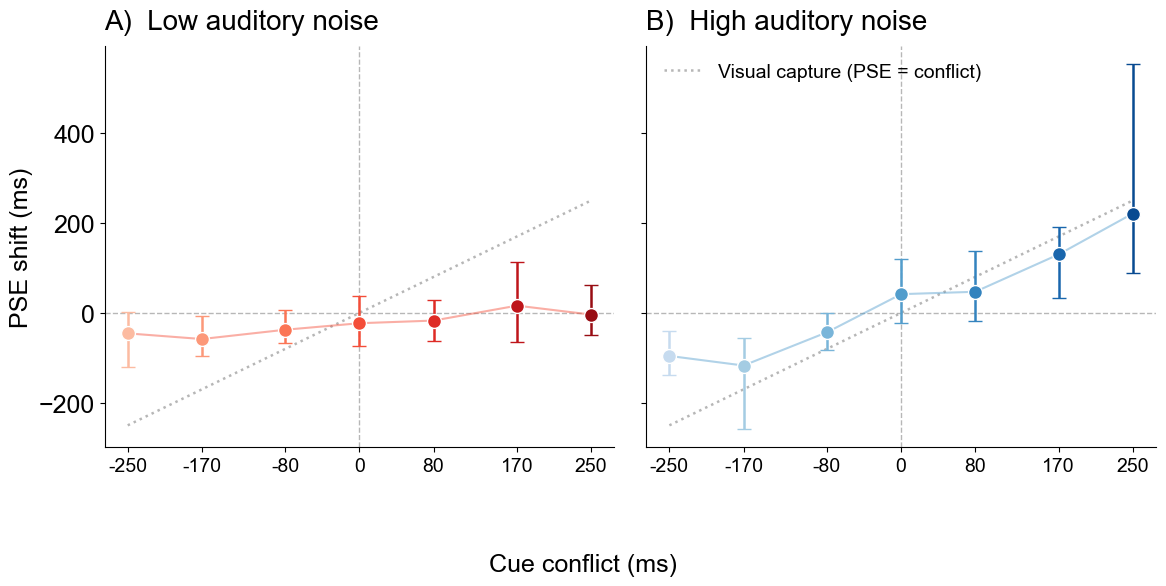

In [13]:
noise_vals = sorted(boot_df['audNoise'].unique())
noise_labels = {noise_vals[0]: 'Low auditory noise',
                noise_vals[1]: 'High auditory noise'}
noise_cmaps_pse = {
    noise_vals[0]: sns.color_palette('Reds', as_cmap=True),
    noise_vals[1]: sns.color_palette('Blues', as_cmap=True),
}
conflict_ticks_ms = sorted(boot_df['conflict_ms'].unique())
n_conflict_levels = len(conflict_ticks_ms)


def conflict_color_pse(noise_val, k, n_total):
    return noise_cmaps_pse[noise_val](0.25 + 0.65 * k / max(n_total - 1, 1))


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
panel_prefix = ['A)', 'B)']
for idx, noise_val in enumerate(noise_vals):
    ax  = axes[idx]
    sub = boot_df[boot_df['audNoise'] == noise_val].sort_values('conflict_ms')
    for k, (_, row) in enumerate(sub.iterrows()):
        color = conflict_color_pse(noise_val, k, n_conflict_levels)
        y     = row['mu_med_ms']
        ylo, yhi = row['mu_lo_ms'], row['mu_hi_ms']
        ax.errorbar(row['conflict_ms'], y,
                    yerr=[[max(0, y - ylo)], [max(0, yhi - y)]],
                    fmt='o', color=color, capsize=5, markersize=10,
                    linewidth=1.8, capthick=1.5,
                    markerfacecolor=color, markeredgecolor='white',
                    markeredgewidth=1.0, zorder=5)
    mid_color = conflict_color_pse(noise_val, n_conflict_levels // 2, n_conflict_levels)
    ax.plot(sub['conflict_ms'], sub['mu_med_ms'],
            color=mid_color, linewidth=1.5, alpha=0.45, zorder=3)
    # Reference lines
    ax.axhline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    conflict_range = np.array(sorted(sub['conflict_ms']))
    ax.plot(conflict_range, conflict_range, color='#aaaaaa', linestyle=':',
            linewidth=1.8, alpha=0.85, zorder=2,
            label='Visual capture (PSE = conflict)' if idx == 1 else None)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[noise_val]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    ax.set_xticks(conflict_ticks_ms)
    ax.set_xticklabels([str(t) for t in conflict_ticks_ms],
                       fontsize=FONT_SIZE_LABEL - 4, rotation=0)
axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT_SIZE_LABEL)
axes[1].legend(fontsize=FONT_SIZE_LEGEND - 6, frameon=False, loc='upper left')
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_pse_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_pse_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. PF σ vs conflict (bonus)

Same conditions, PF width σ instead of PSE. σ is plotted in unitless form: raw log-space σ in `lognormal` mode, or σ divided by the standard duration in `normal` mode.

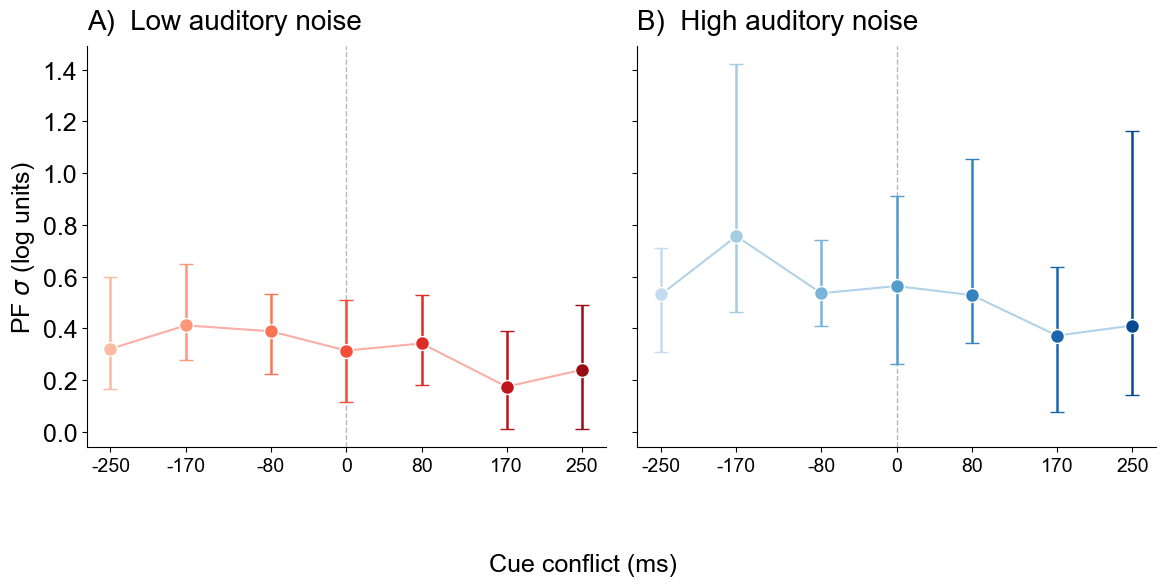

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for idx, noise_val in enumerate(noise_vals):
    ax  = axes[idx]
    sub = boot_df[boot_df['audNoise'] == noise_val].sort_values('conflict_ms')
    for k, (_, row) in enumerate(sub.iterrows()):
        color = conflict_color_pse(noise_val, k, n_conflict_levels)
        y     = row['sigma_med_unitless']
        ylo, yhi = row['sigma_lo_unitless'], row['sigma_hi_unitless']
        ax.errorbar(row['conflict_ms'], y,
                    yerr=[[max(0, y - ylo)], [max(0, yhi - y)]],
                    fmt='o', color=color, capsize=5, markersize=10,
                    linewidth=1.8, capthick=1.5,
                    markerfacecolor=color, markeredgecolor='white',
                    markeredgewidth=1.0, zorder=5)
    mid_color = conflict_color_pse(noise_val, n_conflict_levels // 2, n_conflict_levels)
    ax.plot(sub['conflict_ms'], sub['sigma_med_unitless'],
            color=mid_color, linewidth=1.5, alpha=0.45, zorder=3)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[noise_val]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    ax.set_xticks(conflict_ticks_ms)
    ax.set_xticklabels([str(t) for t in conflict_ticks_ms],
                       fontsize=FONT_SIZE_LABEL - 4, rotation=0)
axes[0].set_ylabel(sigma_plot_label(), fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_sigma_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_sigma_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## Files produced

- `oyExt_psychometric_functions.{pdf,png}` — two-panel PFs (low / high audio noise) with conflicts colour-coded
- `oyExt_pse_vs_conflict.{pdf,png}` — PSE vs conflict with trial-bootstrap 95% CI
- `oyExt_sigma_vs_conflict.{pdf,png}` — unitless PF σ vs conflict with trial-bootstrap 95% CI